## Exercice Les nombres amis

- Q.1

In [1]:
def divStrict(x):etfetf
    for y in range(1,x):
        if x%y==0:
            print(y,end=", ")

In [2]:
divStrict(8)

1, 2, 4, 

<div class="alert alert-success" role="alert">
    
Q.2 **La complexité**

Soit $C: x\mapsto C(x)$, la fonction qui décrit la complexité au pire des cas de la fonction divStrict, en comptant le nombre des d'exécution de l'instruction print, 
    L'instruction print s'exécute au maximaut x-1 fois, du coup la complexité est linéaire, i.e $C(x)=O(x)$
</div>

- Q.3

In [3]:
def somDivStrict(x):
    som=1
    for y in range(2,x):
        if x%y==0:
            som+=y
    return som

In [4]:
somDivStrict(8)

7

- **Q.4**

In [5]:
def amis1(x,y):
    return not bool(x-somDivStrict(y)+ y-somDivStrict(x))

In [6]:
amis=lambda x,y:x==somDivStrict(y) and y==somDivStrict(x)

In [7]:
amis(284,220)

True

**Q.5**

In [8]:
def list_amis(n):
    amisL=list(set([(i,j) if amis(i,j) else (-1,-1) for j in range(2,n+1) for i in range(2,j+1)]))
    amisL.remove((-1,-1))
    return amisL

In [9]:
list_amis(300)

[(6, 6), (28, 28), (220, 284)]

**Q.6**
<div class="alert alert-success" role="alert">

Soit $T: m\mapsto T(m)$, l'application qui designe la compléxité temporelle au pire des cas de la focntion **list_amis**, avec n designe exactement la meme chose pour les deux fonction $T$ et **list_amis**.

nous avons: \
    cout(inst1:=(i,j) if amis(i,j) else (-1,-1))=1, toujours,  il suffit de compter le nombre d'exécution de cette instruction, qui est :
    $$T(n)=1+\Sigma_{j=2}^n \Sigma_{i=2}^j (1)=O(n^2)$$
    
donc la complexité est quadratique.
</div>

------------

## Partie I: Base de données et langages SQL (éLECTIONS)

![Personnes_Votes.png](src/Personnes_Votes.png)

**Q.1**

<div class="alert alert-success" role="alert">
    
```SQL
    
INSERT INTO Personnes(code,nom,prénom,genre) 
VALUES
(123,'GUISSI','MARYAM','F'),
(138,'FORA','AHMED','M')

```
</div>

**Q.2**
<div class="alert alert-info" role="alert">
    
</div>

<div class="alert alert-success" role="alert">
   $$\Pi_{code, nom,prénom}(\sigma_{codC=394}(Personnes \underset{code=codP}{\bowtie} Votes))$$ 
    Ou bien
    
$$\Pi_{code, nom,prénom}(Personnes \underset{code=codP,\text{ } codC=394}{\bowtie} Votes)$$ 

</div>

![src/questions.png](src/questions.png)

**Q.3**
<div class="alert alert-success" role="alert">
    
```SQL
 
SELECT code,nom,prénom
FROM Personnes JOIN Vote
ON code=codP
WHERE codC=394
ORDER BY code ASC
```
    
    
</div>


**Q.4**

<div class="alert alert-success" role="alert">
    
```SQL
SELECT code,nom,prénom,genre
FROM Personnes
WHERE nom like '_ A _ _ _ %'
ORDER BY nom,prénom
```
</div>


**Q.5**

<div class="alert alert-success" role="alert">
    
```SQL
SELECT code,nom,prénom 
FROM Personnes
WHERE genre='M' AND code NOT IN (SELECT codP from Vote)

```
</div>

**Q.5 (bis)**

<div class="alert alert-success" role="alert">
    
```SQL
SELECT code,nom,prénom 
FROM Personnes LEFT JOIN VOTE
ON code=codP
WHERE genre='M' AND codP is NULL

```
</div>

**Q.5 (bis) not yest**

<div class="alert alert-success" role="alert">
    
```SQL
SELECT PC.code,PC.nom,PC.prénom,PC.genre
FROM Personnes AS PE JOIN VOTE JOIN Personnes AS PC
ON PE.code=codP and PC.code=codC
GROUP BY 

```
</div>

# Partie II: Calcul Numérique, Interpolation de Newton

![src/num1.png](src/num1.png)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

**Q.1**

In [11]:
def decoupe(P):
    p=np.array(P)
    return p[:,0],p[:,1]

In [12]:
def decoupe2(P):
    X,Y=[],[]
    for x,y in P:
        X.append(x)
        Y.append(y)
    return X,Y

In [13]:
P=np.array([(-1,2),(0,1),(5,4),(1,3),(-2,8),(-7,3),(3,-3)])
decoupe(P)

(array([-1,  0,  5,  1, -2, -7,  3]), array([ 2,  1,  4,  3,  8,  3, -3]))

In [14]:
X,Y=decoupe2(P)

**Q.2**

In [15]:
def matrice(X):
    n=len(X)
    M=np.zeros((n,n),dtype=int)
    M[:,0]=1
    for i in range(1,n):
        for j in range(1,i+1):
            M[i,j]=int((X[i]-X[j-1])*M[i,j-1])
    return M

In [16]:
X=[-1,0,5,1,-2,-7,3]
M=matrice(X);M

array([[     1,      0,      0,      0,      0,      0,      0],
       [     1,      1,      0,      0,      0,      0,      0],
       [     1,      6,     30,      0,      0,      0,      0],
       [     1,      2,      2,     -8,      0,      0,      0],
       [     1,     -1,      2,    -14,     42,      0,      0],
       [     1,     -6,     42,   -504,   4032, -20160,      0],
       [     1,      4,     12,    -24,    -48,   -240,  -2400]])

**Q.3**

In [17]:
def solution(M,Y):
    X=[1]
    for i in range(1,len(Y)):
        X.append((Y[i]-M[i,:i]@X[:i])/M[i,i])
    return X

In [18]:
A=solution(M,Y);A

[1,
 0.0,
 0.1,
 -0.225,
 0.08690476190476192,
 0.023115079365079366,
 0.00036706349206349227]

**Q.4**
![src/num2.png](src/num2.png)

In [19]:
def valeur(x,A,X):
    s=0;n=len(X)
    for i in range(n):
        p=1
        for j in range(i):
            p*=x-X[j]
        s+=A[i]*p
    return s

**Q.5**

In [20]:
def courbe(P):
    X,Y=decoupe(P)
    M=matrice(X)
    A=solution(M,Y)
    t=np.linspace(min(X),max(X),500)
    yt=[valeur(tt,A,X) for tt in t]
    plt.scatter(X,Y)
    plt.plot(t,yt)

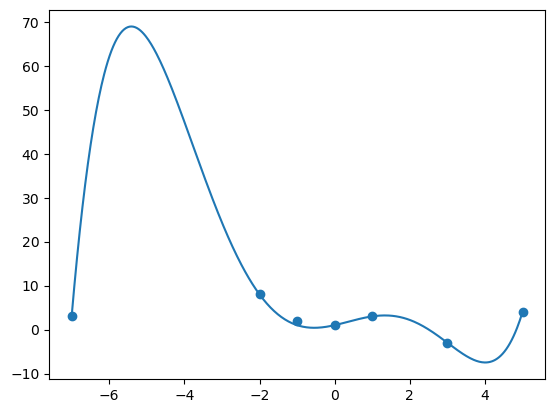

In [21]:
courbe(P)

# Parie III: Problème (Fonction de Hashage)

## La fonction SHA-256

Une fonction de hachage, de l'anglais hash function (hash : pagaille, désordre, recouper et mélanger par analogie avec la cuisine) est une fonction particulière qui, à partir dune donnée fournie en entrée, calcule une valeur de sortie servant à identifier rapidement la donnée initiale, au même titre qu'une signature pour identifier une personne. La donnée d'entrée de ces fonctions est souvent appelée message ; la valeur de sortie est souvent appelée, empreinte numérique, ou haché.
Une fonction de hachage idéale posséde les propriétés suivantes :
- la fonction est déterministe, c'est-à-dire qu'un même message aura toujours la même valeur de hachage ;
- il est impossible, pour une valeur de hachage donnée, de construire un message ayant cette valeur ;
- il est impossible de trouver deux messages différents ayant la même valeur de hachage (résistance aux collisions) ;
- la modification dans le message modifie considérablement la valeur de hachage.
Les fonctions de hachage sont utilisées en informatique et en cryptographie. Une application importante du hachage cryptographique est la vérification de rintégrité dun fichier ou duun message. Par exemple, la modification dun fichier lors duune transmission (ou toute autre activité) peut etre prouvée en comparant la valeur de hachage du fichier avant et après la transmission.

Une autre application du hachage cryptographique est la vérification de mot de passe. Le stockage de tous les mots de passe utilisateur en clair peut entrainer une violation de sécurité massive si le fichier de mots de passe est compromis. Une façon de réduire ce danger est de stocker seulement la valeur de hachage de chaque mot de passe. Pour authentifier un usager, le mot de passe foumi par lutilisateur est haché et comparé avec la valeur de hachage stockée. Avec cette approche, les mots de passe perdus ne peuvent pas être récupérés s'ils sont oubliés; ils doivent être remplacés par de nouveaux mots de passe.

Les fonctions de hachage, y en a plusieurs : MD4, MD5, SHA-1, SHA-224, SHA-256, SHA-384, .... Dans la suite de cette partie, nous nous intéresseront à la fonction de hachage SHA-256.

En 2002, la fonction de hachage SHA-256 devient un standard fédéral de traitement de l'information. A partir d'un texte de taille maximale $2^{64}$ bits (c.à.d. 2 Péta-octets), cette fonction produit un haché de 256 bits, représenté par 64 caractères hexadécimaux.
Exemples :
> Le haché du message 'Concours CNC 2023' est :
**'ff33dfa67e2c471aa85a83c7a4632955594a946t38ac4a5904873ad5c64f9894'**
Le haché du message 'Concours CNC MP-2023' est :
**'O+3503b5ac59d7160ed4c579d7548100c326c47a8673f36031e27d42e099e3a3'**

L'objectif de cette partie est d'implémenter l'algorithme du hachage SHA-256, en langage python.

A-Manipulation des bits
Q.1- Ecrire ia fonetion NON $(X)$ quil reçoit en parametre une chaine de caracteres $X$ de taille 32, contenant une representation binaire. La lonction retourne ia chaine de caracteres $\mathbf{Z}$ de taille 32 . Les $\dot{16}$ bents $z i$ de la chalne $\mathbf{Z}$ sont calculbs en utllsant ralgorithme suivant :
$x i$ est un element dindice $I$ dans $x$ :
> Si $x=10$ ' 0 alors $z i=' 1$ '
$>\operatorname{Si} x={ }^{\prime} \mathrm{T}$ ' alors $\boldsymbol{z} \mid=$ ' $^{\prime} 0$ '
Fxemple : NON (01000011010011100100001100100000) retourne la chaine de caracteres : '10111100101100011011110011011111'
Q.2- Ecrire la fonction ET $(\boldsymbol{X}, \boldsymbol{Y})$ qui reçoit en paramètres deux chalines de caracteres $X$ et $Y$ de mème taille 32, contenant respectivement deux représentations binaires. La fonction retourne la chaỉne de caractères $Z$ de taille 32. Les elements $z i$ de la chaine $Z$ sont calculés en utilisant ralgorithme suivant :
$x ;$ et $y$ sont respectivement deux élements de $X$ et $Y$, de méme indice $i$ :
Si $x i=$ ' 1 ' et $y=$ ' 1 ' alors $z i=' 1$ '
$>$ Si $x={ }^{\prime} 0$ ' ou $y=' 0$ ' alors $z=' 0$ '
Exemple : ET ('01000011010011100100001100100000', "00110010001100000011001000110011) retoume la chaine : '00000010000000000000001000100000'
Q.3- Ecrire la fonction $X O A(X, Y)$ qui reçoit en parametres deux chaines de caracteres $X$ et $Y$ de mème taille 32, contenant respectivement deux représentations binaires. La fonction retoume la chaine de caractéres $z$ de taille 32. Les elements $z i$ de la chaine $Z$ sont calculés en utilisant ralgorithme suivant :
$x i$ et $y$ sont respectivement deux elements de $X$ et $Y$, de méme indice $I$ :
$>$ Si $x=y$ alors $z i=' 1$ '
$>\mathrm{Si} x \neq y$ ilors $z i=' 0$ '
Exemple : XOR ('01000011010011100100001100100000', '00110010001100000011001000110011') retourne la chaine : "01110001011111100111000100010011"

Q.4. Ecrire la fonction decal_droite $(X, p)$ qui rep̧oit en paramètres une chaine de caractères $X$ de taille 32, contenant une représentation binaire, et un entier $p$ tel que $1 \leq p<32$. La fonction décale les bits de $X$ de $p$ positions vers la droite : Supprimer les $p$ demiers bits de $X$, et ajouter $p$ fois le bit ' 0 ' au début de $X$.
Exemple : decal_droite ('01000011010011100100001100100111', 8) retourne la chaine de caractères : '00000000010000110100111001000011'

Q.5. Ecrire la fonction rotation_drolte $(X, p)$ quil repoit en parametres une chaine de caractères $X$ de tallie 32, contenant une représentation binaire, et un entier $p$, tel que $1 \leq p<32$. La fonction effectue une rotation des bits de $X$ de $p$ positions vers la droite: Déplacer les derniers $p$ bits de $X$ au debut de $X$.
Exemple : rotation_droite ('01000011010011100100001100100111', 12) retourne la chaine de caractères : '00110010011101000011010011100100'

In [1]:
def non1(X):
    trans={ord('0'):ord('1'),ord('1'):ord('0')}
    Z=X[:]
    Z=Z.translate(trans)
    return Z

In [2]:
non1("010101")

'101010'

In [3]:
def non2(X):
    return "".join(['1' if x=='0' else '0' for x in X])

In [4]:
non2('010101')

'101010'

In [5]:
def non3(X):
    Z=""
    for x in X:
        Z+='1' if x=='0' else '0'
    return Z

In [6]:
non3('010101')

'101010'

In [7]:
def non4(X):
    Z=[]
    for x in X:
        if x=='0':
            Z.append('1')
        else:
            Z.append('0')
    return "".join(Z)

In [8]:
non4('010101')

'101010'

In [10]:
a="123"
b="569"

[('1', '5'), ('2', '6'), ('3', '9')]

In [11]:
int('0')*int('1')

0

In [19]:
def ET(X,Y):
    Z=""
    for x,y in zip(X,Y):
        Z+="1" if(x=="1"and y=="1") else "0"
    return Z

In [20]:
def ET1(X,Y):
    return "".join([str(int(x)*int(y)) for x,y in zip(X,Y)])

In [21]:
ET('101','110')

'100'

In [23]:
int(False)

0

In [32]:
def XOR(X,Y):
    return "".join([str(int(x==y)) for x,y in zip(X,Y)])

In [33]:
def XOR1(X,Y):
    Z=""
    for x,y in zip(X,Y):
        Z+=str(int(x==y))
    return Z

In [34]:
XOR1("101","011")

'001'

In [ ]:
def decal_droit(X,p):
    

In [42]:
def decal_droit(X,p):
    return "0"*p+X[:-p]

In [43]:
X="101"*10+"11"
decal_droit(X,5)

'00000101101101101101101101101101'

In [49]:
def rotation_droite(X,p):
    return X[-p:]+X[:-p]

In [50]:
X='123456789azerfdsqwxcvgbtyhnjuiopm'

In [51]:
rotation_droite(X,3)

'opm123456789azerfdsqwxcvgbtyhnjui'

In [59]:
def addition(X,Y):
    n=len(X)
    r=0
    Z=""
    for i in range(n-1,-1,-1):
        val=(int(X[i])+int(Y[i])+r)
        Z=str(val%2)+Z
        r=val//2
    return Z

In [60]:
addition("101",'111')

'100'

In [74]:
"123"[:-1]

'12'

In [75]:
def addition_rec(X,Y,r=0):
    if X=="" or Y=="":
        return ""
    val=int(X[-1])+int(Y[-1])+r
    return addition_rec(X[:-1],Y[:-1],val//2)+str(val%2)

In [73]:
addition_rec("1011",'1110')

'1001'

Q.6. Ecrire la fonction addition $(X, Y)$ qui rȩ̣olt en paramètres deux chaines de caractères $X$ et $Y$ de même taille 32, contenant respectivement deux reprósentations binaires. La fonction retourne la chaine de caractères de taille 32, résultat du calcul en modulo $2^{22}$, de l'addition binaire de $X$ et $Y$.
L'addition binaire utlise le principe suivant :
$0+0=0$
$0+1=1$
$1+0=1$
$1+0=10$ (on pose 0 et on retient t)
- $1+1+1=11$ (on pose 1 et on retient 1$)$
Exemple : addition ("11111111111111111111111111111010', "00000000000000000000000000011100') retoume la chaine de caractères : '00000000000000000000000000010110'
B-Initialisation des variables de hachage
L'algorithme SHA-256 utilise 8 variables globales : ho, $h 1, h 2, h 3, h 4, h 5, h 6, h 7$ et $h 8$. Ces variables sont initialiseses respectivement par les chaines de caractères contenant les premiers 32 bits des représentations binaires, des partes fractionnaires des racines camées des 8 premiers nombres premiers : 2, 3, 5, 7, 11, 13, 17 et 19.
Fxemple:
La racine carrèe de 2 est 1.4142135623730951. Sa partie fractionnaire est 0.4142135623730951 La représentation binaire de cette partie fractionnaire est ; 0.01101010000010011110011001100111111... La variable ho est initialisee par les premiers 32 bits : "01101010000010011110011001100111". L'algorithme SHA-256 utlise aussi une variable globale $K$ initialisee par une liste composée de 64 constantes. La liste $K$ est initialisede respectivement par les chaines de caracteres contenant les premiers 32 bits des représentations binaires, des parties fractionnaires des facines cubiques des 64 premiers nombres premiers : $3,5,7,11,13,17,19 \ldots$ et 311.
On suppose que $L$ est une variable globale initialisee par les 64 premiers nombres premiers :
$$
L=[2,3,5,7,11,13,17,19,23,29,31,37,41,43,47,53,59, \ldots, 269,271,277,281,283,293,307,311]
$$
NB : Pour calculer $\sqrt[m]{x}$ (la racine nième d'un entier $x$ ), on utilise la syntaxe suivante : $x^{* n}(1 / n)$
Q.7- Ecrire la fonction bin_fract $(x, n)$ qui reçoit en paramêtres un nombre premier $x$ et entier $n>1$. La fonction retourne la chaine de caractères contenant les premiers 32 bits de la repressentation binaires, de la partie fractionnalie de $\sqrt[m]{x}$.
Fxemples :
- bin_fract $(7,2)$ retoume la chaine de caracteres : '10100101010011111111010100111010'
- bin_fract $(7,3)$ retourne la chaine de caracteres : '11101001101101011101101110100101'
Q.8- Ecrire la fonction liste_init $(t, n)$ qui reçoit en parametres un entier strictement positif $t \leq 64$ et un entier n>1. La fonction retoume une liste composede des chalnes de caracteres contenant les premiers 32 bits des représentations binaires, des parties fractionnaires des racines nंinet des $t$ premiers nombres premiers.
Exemple : liste init $(4,2)$ retourne la liste :
["01101010000010011110011001100111', "10111011011001111010111010000101', '00111100011011101111001101110010', '10100101010011111111010100111010']

## Initialisation des  variables de hashage

## 🔹 Q.9 — Initialisation des variables globales de hachage

Écrire les instructions permettant d'initialiser les variables globales de hachage :  
$h_0, h_1, h_2, h_3, h_4, h_5, h_6, h_7$ et $K$.

---

## 🔹 C — Préparation du message

Le message qui sera haché est représenté par une **liste contenant les codes des caractères** du message.

Par exemple, les codes des caractères du message **"Concours CNC MP-2023"** sont :

| C | o | n | c | o | u | r | s | (espace) | C | N | C | (espace) | M | P | - | 2 | 0 | 2 | 3 |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| 67 | 111 | 110 | 99 | 111 | 117 | 114 | 115 | 32 | 67 | 78 | 67 | 32 | 77 | 80 | 45 | 50 | 48 | 50 | 51 |

Donc, le message `"Concours CNC MP-2023"` est représenté par la liste $T$ suivante :

$$
T = [67, 111, 110, 99, 111, 117, 114, 115, 32, 67, 78, 67, 32, 77, 80, 45, 50, 48, 50, 51]
$$

**NB :** On suppose que les éléments de la liste $T$ sont tous des entiers positifs inférieurs strictement à 256.

La préparation du message consiste à transformer la liste des codes $T$ en une chaîne de caractères $B$ dont la taille est un multiple de 512, et qui contient :
- les **conversions binaires** des éléments de $T$,
- ainsi que la **conversion binaire** de la taille de $T$.  

La chaîne $B$ sera ensuite découpée dans une liste de sous-chaînes.

---

## 🔹 Q.10 — Fonction `binaire(x, t)`

Écrire la fonction `binaire(x, t)` qui reçoit en paramètres deux entiers positifs $x$ et $t$ tels que $0 \leq x < 2^t$.  
La fonction retourne une chaîne de caractères de taille $t$, contenant la conversion binaire de $x$.

**Exemple :**

$$
\text{binaire}(67, 8) \Rightarrow "01000011"
$$

---



## 🔹 Q.11 — Fonction `binaire_txt(T)`

Écrire la fonction `binaire_txt(T)` qui reçoit en paramètre une liste `T` contenant les codes des caractères d’un message.  
La fonction retourne une chaîne de caractères $B$, contenant la concaténation des conversions binaires des éléments de `T`.  
Chaque élément de `T` est converti sur **8 bits**.

**Exemple :**

$$
T = [67,111,110,99,111,117,114,115,32,67,78,67,32,77,80,45,50,48,50,51]
$$




$$ \text(binaire txt)$$
$$\rightarrow "0100001101101111011011100110001101101111011101010111001001110011001000000100001101001110010000110010000001001101010100000010110100110010001100000011001000110011"
$$


---

## 🔹 Q.12 — Fonction `remplissage(B)`

Écrire la fonction `remplissage(B)` qui reçoit en paramètre la chaîne de caractères `B`, contenant la conversion binaire du message.  
La fonction effectue les opérations suivantes :

1. Soit $n = \text{longueur}(B)$  
2. Ajouter le bit `'1'` à la fin de la chaîne `B`  
3. Ajouter des bits `'0'` à la fin de `B` jusqu’à ce que la longueur de `B` modulo 512 soit égale à 448  
4. Convertir le nombre $n$ en binaire sur 64 bits, dans une chaîne de caractères, et l’ajouter à la fin de `B`  
5. Retourner la nouvelle chaîne `B` (de taille multiple de 512)

---

### 🧩 Exemple

Chaîne $B$ de taille $n = 160$ :


![src/hash4.png](src/hash4.png)


Q.13- Ecrire ia foncton decoupe (B) qui reçeit en parambtre la chaine de caractères $\boldsymbol{B}$ dont la taille est un mulliple de 512. La fonction effectue le decoupage suivant, de la chaine $B$ :
7 La chaline $\theta$ est decoupee en $p$ sous chaines de talle 512 chacune (avec pataille(B) 512$)$;
7 Chaque sous chalne de taille 512 est decouple en 16 sout chaines de taille 32 chacune. Ces 16 sous chalnes sont rangees dans une sous liste $w$;
7 $W$ est une liste qui contiendra les $p$ sous listes $w$ de taille 32 chacune:
> La fonction retourne la liste de listes $W$.
Exemple :
Sous liste de taille 16
Chaines de taille 32
$W=$ [ '01000011011011110110111001100011', $\left.01101111011101010111001001110011^{\prime}, \ldots,\right]$, ['T0001011001011010101001100110100', "01011111010011010100111001110110',... ]. ]
D. Compression
Pour chaque sous liste $w$ de la liste $W$, on modifie les 8 variables de hachage, at raide de Falgorithme sulvant : Ajouter a la fin de la liste $w, 48$ chalines de taille 32, initialisbes a '0000000... $000^{\prime}(0$ repefe 32 fois) Pour i= 16 a 63 faire

### Q.13 — Calcul des mots de message étendus

L’étape suivante consiste à **étendre les mots du message** en 64 mots notés $w[0]$ à $w[63]$.

Les 16 premiers mots proviennent directement du bloc du message préparé.  
Pour $i$ allant de 16 à 63, on calcule :

$$
S_0 \leftarrow (\text{rotation\_droite}(w[i-15], 7)) \oplus (\text{rotation\_droite}(w[i-15], 18)) \oplus (\text{décalage\_droite}(w[i-15], 3))
$$

$$
S_1 \leftarrow (\text{rotation\_droite}(w[i-2], 17)) \oplus (\text{rotation\_droite}(w[i-2], 19)) \oplus (\text{décalage\_droite}(w[i-2], 10))
$$

$$
w[i] \leftarrow w[i-16] + S_0 + w[i-7] + S_1
$$

**Fin Pour**

---

### Q.14 — Boucle principale

Pour $i = 0$ à $63$, faire :

$$
\begin{cases}
S_1 = (\text{rotation\_droite}(e, 6)) \oplus (\text{rotation\_droite}(e, 11)) \oplus (\text{rotation\_droite}(e, 25)) \\
\text{Ch} = (e \land f) \oplus (\lnot e \land g) \\
\text{Temp}_1 = h + S_1 + \text{Ch} + K[i] + w[i] \\
S_0 = (\text{rotation\_droite}(a, 2)) \oplus (\text{rotation\_droite}(a, 13)) \oplus (\text{rotation\_droite}(a, 22)) \\
\text{Maj} = (a \land b) \oplus (a \land c) \oplus (b \land c) \\
\text{Temp}_2 = S_0 + \text{Maj}
\end{cases}
$$

Puis mettre à jour les variables :

$$
\begin{aligned}
h &\leftarrow g \\
g &\leftarrow f \\
f &\leftarrow e \\
e &\leftarrow d + \text{Temp}_1 \\
d &\leftarrow c \\
c &\leftarrow b \\
b &\leftarrow a \\
a &\leftarrow \text{Temp}_1 + \text{Temp}_2
\end{aligned}
$$



$50 \leftarrow($ e rocation_Droite 6$)$ xor (e rotation_Droite 11) xor (e rotation_Droite 25) ch $\leftarrow(e$ and $f)$ xor (non e and $g$ )
tmp $1 \in \mathrm{h}+\mathrm{SO}+\mathrm{ch}+\mathrm{K}[\mathrm{i}]+\mathrm{w}[\mathrm{i}]$
$S 1 \leftarrow($ a rotation_Droite 2) xor (a rotation_Droite 13) xor (a rotation_Droite 22) maj $\leftarrow$ (a and b) xor ( $a$ and $c)$ xor (b and c)
$\operatorname{tmp} 2 \in \mathrm{S} 1+\mathrm{maj}$
$h \in g$
g.
$f \in e$
$e \in d+$ tmpl
$d \in c$
$c \in b$
$b \in a$
a $\leftarrow \operatorname{tmp} 1+\operatorname{tmp} 2$
Fin Pour
Additionner a, b, c, d, c, f, g, h respectivement à ho, h1, h2, h3, h4, h5, h6, h7

![src/hash6.png](src/hash6.png)

Q.14- Ecrire la fonction compression $(W)$ quil effectue le trailement de ralgorithme ci-dessus, pour chaque sous liste $\boldsymbol{w}$ de la liste $W$.
E- Calcul du haché final
Le haché final est obtenu par la concaténation des 8 variables globale de hachage. Ainsi, on obtient une chaine $\boldsymbol{H}$ de longueur 256 bits. Le haché final est la conversion de $H$ en hexadécimale : chaque groupement de 4 bits dans $\mathrm{H}$ est remplacé par sa valeur en hexadécimale.
Exemple :
$$
\begin{aligned}
& \text { ho }=\text { ' } 00001111001101010000001110110101^{\prime} \\
& \text { h2 = '00001110110101001100010101111001' } \\
& h 4=\text { '11000011001001101100010001111010' } \\
& h 6=\text { ' } 00110001111000100111110101000010^{\prime} \\
&
\end{aligned}
$$

h1 $=' 10101100010110011101011100010110$ \
h3 $=' 11010111010101001000000100000000$ \
h5 $=' 10000110011100111111001101100000$ \
h7 $=' 11100000100110011110001110100011$

La chaine de caractères $\mathrm{H}$ est la concaténation des 8 variables globales de hachage h0, h1, h2, h3, h4, h5, $\mathrm{h} 6$ et $\mathrm{h} 7$ :
'00001111001101010000001110110101101011000101100111010111000101100000111011010100110001 01011110011101011101010100100000010000000011000011001001101100010001111010100001100111 $00111111001101100000001100011110001001111010100001011100000100110011110001110100011^{\prime}$
Ensuite, chaque groupement de 4 bits dans $H$ est remplace par sa valeur en hexadécimale :



|0000 | 1111 | 0011 | 0101 | 0000 | 0011 | 1011 | 0101 | 1010 | 1100 | $\ldots$ | 0011 | 1010 | 0011 |
|-|-|-|-|-|-|-|-|-|-|-|-|-|-|
|$\mathbf{0}$ | $\mathbf{f}$ | $\mathbf{3}$ | $\mathbf{5}$ | $\mathbf{0}$ | $\mathbf{3}$ | $\mathrm{b}$ | $\mathbf{5}$ | a | c | $\ldots$ | $\mathbf{3}$ | $\mathbf{a}$ | $\mathbf{3}$ |

\hline
En fin, le haché final est composé des 64 caractères hexadécimaux :
'Of3503b5ac59d7160ed4c579d7548100c326c47a8673f36031e27d42e099e3a3'
Q.15. Ecrire la fonction hache_final() qui retourne le hache final